# 第3课 · 练出一双「看见」声音的眼睛——谱图（spectrogram）直觉，先读图后学 FFT

**学习目标**
1. 读懂谱图的三个轴（时间 × 频率 × 能量）
2. 在看图中区分纯音（pure tone）、和弦（chord）、扫频（frequency sweep）、噪声
3. 建立「谱图 = L32–L53（音频 DSP 模块）学完后能亲手算出来的图」的直觉

> ⚠️ 本课**不推导任何公式**，只建立视觉直觉。
> FFT 和 STFT 的数学推导在 L37-L45。

← **上一课**　[L02 · 采样与第一声正弦波](L02_sound_digital.ipynb)

> 上节课学习了 **采样与数字声音**：采样率、时间轴、第一声可听正弦波。  
> 本课将探讨 **谱图直觉**——先学会读时频图，再谈怎么算。

## 1. 什么是谱图？

你听过乐队演奏吗？现场时，你能同时分辨出鼓、吉他和人声——哪怕它们同时响着。你的耳朵在实时做一件事：**把声音按频率分解，告诉你每个频率"有多响"**。

谱图（Spectrogram）做的正是这件事，只是它把结果画出来了：

```
纵轴 ↑  频率 (Hz)    高频 ─── 小提琴的高音、齿音
│
│       ████ ← 亮 = 这个频率能量高
│
│       ░░░░ ← 暗 = 这个频率几乎没有
│
低频 ─── 低音鼓、人声基频
└────────────────────→ 时间 (s)
```

三个轴的含义：
- **横轴**：时间——从左到右是声音的流逝
- **纵轴**：频率——从低（鼓声）到高（口哨）
- **颜色/亮度**：能量——越亮代表这个频率在这个时刻越响

读懂谱图，你就有了一双能"看见"声音的眼睛。后面的 FFT（L37）和 STFT（L43）就是计算谱图的数学机器——但先把图读懂，数学才有意义。

> **本课用的望远镜**：下面会用 `plt.specgram` 等库函数**画图**——把它们当成望远镜就好；望远镜镜筒内部怎么磨、怎么装，L43 起再拆开亲手做。

**合上眼复述三轴（检查清单，不是新知识）**：
1. 这一列是哪个时间片？
2. 这一行对应哪个频率？
3. 这块亮表示能量大还是小？

## 开课前：三轴检查清单（与 §1 同一套，合上眼复述用）

和上一节末尾的三问完全同一套轴——这里只当**自检卡**，不重复讲新内容：

- 时间轴：横轴是采样点对应的秒数
- 频率轴：纵轴是 Hz，越高越靠上
- 能量轴：颜色越亮，能量越大

L32 会把这三根轴从原始采样点再画一遍（不是现成谱图）。答不上三问就翻回 §1 的 ASCII 图。

### 开工前先认识两个小词：bin 和 hop（下一格注释里会出现）

下一格代码的注释里有两个本课程第一次出现的词。它们不是你漏学了哪一课——是两个 L43 才正式讲的概念，这里先用大白话把最低限度的意思说清：

- **bin（频率格子）**：谱图的纵轴（频率轴）**不是连续的**，它像一排抽屉、或者尺子上的刻度。
  每个抽屉的宽度 = 采样率 ÷ NFFT。比如 sr=16000、NFFT=256 时，每个抽屉宽 16000 ÷ 256 = **62.5 Hz**。
  一个频率来了，只能被放进**离它最近的抽屉**。所以一个 440 Hz 的纯音，机器读出来的峰值可能是
  437.5 Hz（= 62.5 × 7，离 440 最近的格线）——本课结尾的验证格里你会亲眼看到这个数字，
  **那不是你跑错了，是尺子本身带格子**。
- **hop（跳步）**：谱图是把长声音切成一小片一小片、每片单独分析再拼起来的。每次向右挪动多少个
  采样点再切下一片，就叫 hop。挪得越密（hop 越小），横轴（时间轴）方向的图看起来越平滑连续。

下一格注释里还有一句括号里的纠错（"分辨率由 hop 决定，不是 overlap 本身"）——那是写给**将来学完
L43 回头复习的你**看的，现在读不懂完全正常，直接跳过即可。

本课你只需要记住一句话：**频率轴是一把带格子的尺子，读数和真实频率最多差半格。**

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


观察：一条水平亮线，位于 440 Hz，贯穿整个时间轴。


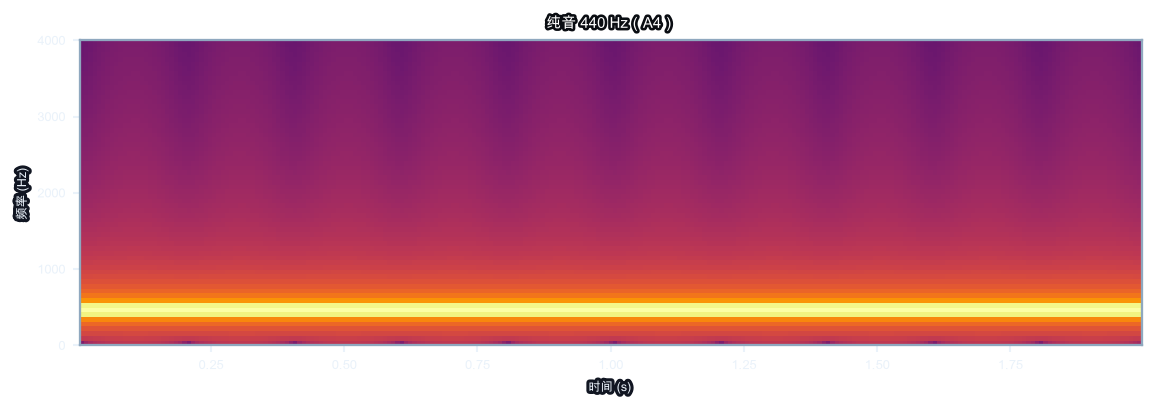

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 工具：用 matplotlib.pyplot.specgram 显示谱图
# （L43–L45 将从零实现这背后的 STFT 算法；现在只需看图）
#
# 两个参数现在不用理解，L43 会细讲：
#   NFFT=256    每帧取 256 个采样点做 FFT → 频率分辨率 = sr/NFFT = 62.5 Hz/bin
#   noverlap=128  相邻帧重叠 128 点 → 每步跳 128 点（hop）= 8 ms，显示更连续（分辨率由 hop 决定，不是 overlap 本身）
def show_spec(signal, sr, title, ax, ylim=4000):
    ax.specgram(signal, Fs=sr, cmap='inferno', NFFT=256, noverlap=128)
    ax.set_ylim(0, ylim)
    ax.set_xlabel('时间 (s)'); ax.set_ylabel('频率 (Hz)')
    ax.set_title(title)

# L02 里你实现的 make_sine(duration, sr, freq) 封装的正是下面这行 np.sin
# 本课直接用 np.sin 构造信号，让你把注意力放在「看图」上
sr = 16000
t  = np.linspace(0, 2, 2 * sr, endpoint=False)

# 纯音：440 Hz 正弦波
pure_tone = np.sin(2 * np.pi * 440 * t)

fig, ax = plt.subplots(figsize=(8, 3))
show_spec(pure_tone, sr, '纯音 440 Hz（A4）', ax)
plt.tight_layout(); plt.show()
print('观察：一条水平亮线，位于 440 Hz，贯穿整个时间轴。')

### 读图：纯音的特征

- **一条水平亮线** = 整段时间内只有一个频率
- 线的位置 = 频率（440 Hz ≈ Y 轴 440 处）
- 线的亮度 = 能量（全程不变 = 振幅恒定）

音频 DSP 模块（L32–L53）结束时，你应能从这张图的数学原理开始，推导出 `plt.specgram` 内部的每一步计算——那是可检验的终点，不是空话。

观察：三条水平亮线，对应 C4=261 Hz, E4=330 Hz, G4=392 Hz。


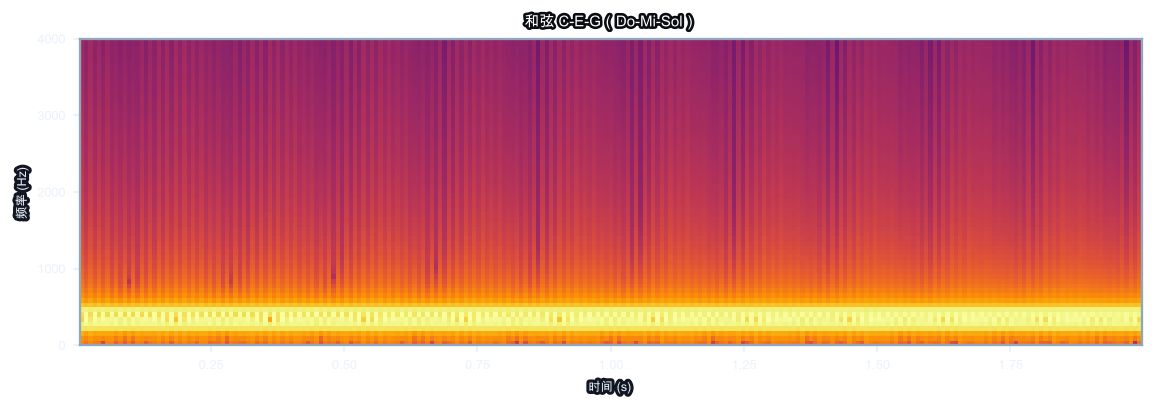

In [3]:
# 和弦：三个频率同时响
chord = (
    np.sin(2 * np.pi * 261.6 * t) +   # C4
    np.sin(2 * np.pi * 329.6 * t) +   # E4
    np.sin(2 * np.pi * 392.0 * t)     # G4
) / 3.0

fig, ax = plt.subplots(figsize=(8, 3))
show_spec(chord, sr, '和弦 C-E-G（Do-Mi-Sol）', ax)
plt.tight_layout(); plt.show()
print('观察：三条水平亮线，对应 C4=261 Hz, E4=330 Hz, G4=392 Hz。')

### ⚠️ 预警：下一格有一行"长得吓人"的代码，先给你台阶

下一格要制造"频率从 200 Hz 匀速爬到 3000 Hz"的扫频声。你的第一直觉多半是：
频率随时间变化是 f(t) = f0 + (f1−f0)·t/T，那直接把它塞进正弦不就行了？——
`np.sin(2*np.pi * f(t) * t)`。

**先说结论：这个最自然的直觉写法是错的。** 它画出来的斜线不会停在 3000 Hz，而是一路飙到
接近 **5800 Hz**，几乎是目标的两倍（下下格有并排对比图，你可以亲眼看到、亲手改数字试）。

为什么？用开车打个比方：

- **频率**像**时速表**：此刻转多快；
- 正弦函数括号里的那坨东西（术语叫"相位"）像**里程表**：从出发到现在一共"转过了多少圈"。

车速一直在变的时候，里程**不能**用「当前时速 × 总时间」来算——那等于把前面开得慢的路段
也按最后的高速记账，里程当然虚高。正确做法是把每一小段时间里「当时的速度 × 那一小段时间」
一点点**累加**起来。把这种"一点点累加"写成数学，就是注释里"积分形式"四个字的含义。

对"匀加速"的情形，累加出来的结果恰好带一个 t²/2——你在高中物理其实见过它：
匀加速运动的位移公式 s = v₀t + at²/2。把"速度"换成"频率"、"位移"换成"相位"，
就是下一格那行代码，一个字都不多。

**本课不要求你会推这一步。** 只要带走一句话：
**相位是频率一点点攒出来的里程，不是"当前频率 × 总时间"。** 完整推导会在 L37 之前给出，
现在照抄这行代码、看图确认"斜线确实从 200 爬到 3000"即可。

观察：一条斜线从低频向高频上升，就像演奏中的滑音。


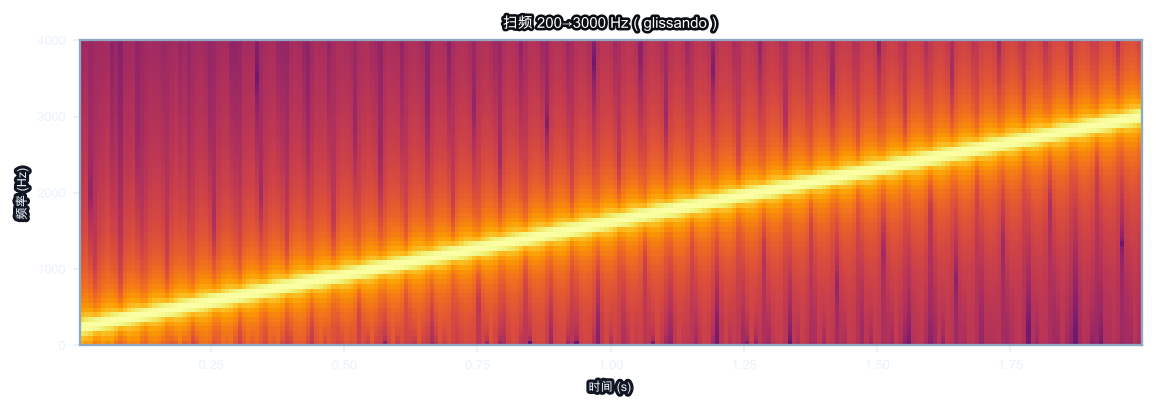

In [4]:
# 扫频（glissando）：频率随时间线性升高
f0, f1 = 200, 3000  # 从 200 Hz 扫到 3000 Hz
sweep = np.sin(2 * np.pi * (f0 * t + (f1 - f0) * t**2 / (2 * t[-1])))  # 积分形式，瞬时频率 f(t)=f0+(f1-f0)t/T

fig, ax = plt.subplots(figsize=(8, 3))
show_spec(sweep, sr, '扫频 200→3000 Hz（glissando）', ax)
plt.tight_layout(); plt.show()
print('观察：一条斜线从低频向高频上升，就像演奏中的滑音。')

直觉写法结尾的实际频率 ≈ 5800 Hz，而不是 3000 Hz
这就是"里程 ≠ 当前时速 × 总时间"——相位必须一点点累加。


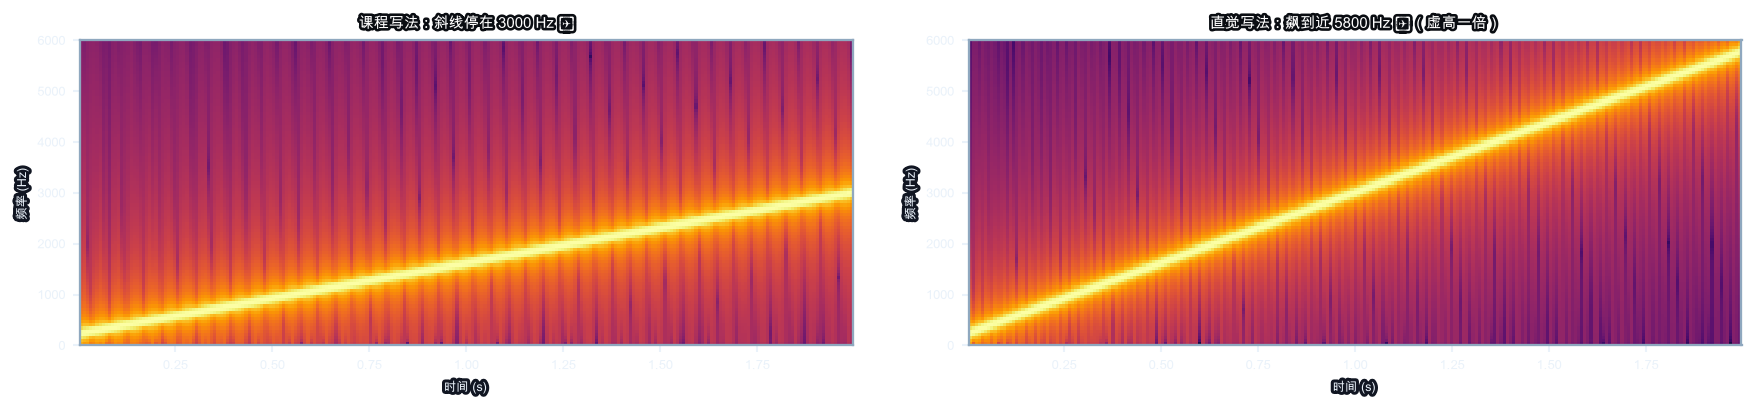

In [5]:
# 眼见为实：把"直觉写法"和"课程写法"并排画出来
# 直觉写法 sin(2π·f(t)·t) —— 上一格预警说它是错的，错在哪里一看便知
T = t[-1]
wrong_sweep = np.sin(2 * np.pi * (f0 + (f1 - f0) * t / T) * t)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
show_spec(sweep,       sr, '课程写法：斜线停在 3000 Hz ✅',        axes[0], ylim=6000)
show_spec(wrong_sweep, sr, '直觉写法：飙到近 5800 Hz ❌（虚高一倍）', axes[1], ylim=6000)
plt.tight_layout(); plt.show()

# 直觉写法的实际瞬时频率其实是 f0 + 2·(f1-f0)·t/T（结尾恰好虚高一倍）
print(f'直觉写法结尾的实际频率 ≈ {f0 + 2 * (f1 - f0)} Hz，而不是 {f1} Hz')
print('这就是"里程 ≠ 当前时速 × 总时间"——相位必须一点点累加。')

观察：整张图均匀地亮——所有频率、所有时刻都有能量。


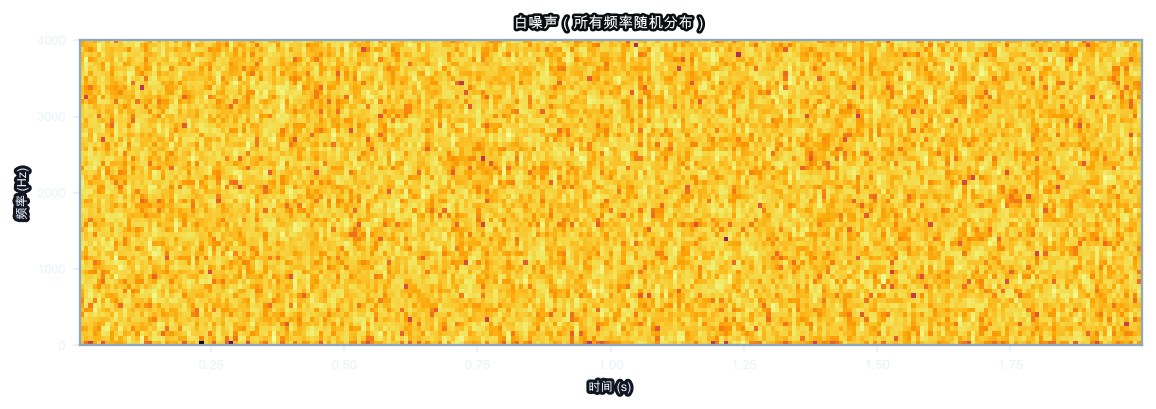

In [6]:
# 白噪声：所有频率同时随机响
rng = np.random.default_rng(42)
noise = rng.standard_normal(len(t))

fig, ax = plt.subplots(figsize=(8, 3))
show_spec(noise, sr, '白噪声（所有频率随机分布）', ax)
plt.tight_layout(); plt.show()
print('观察：整张图均匀地亮——所有频率、所有时刻都有能量。')

### 停一下：为什么"每个点扔一次骰子"就等于"所有频率都有能量"？

上面的代码只做了一件事——每个采样点独立地取一个随机数。这明明是**时间上**随机，
谱图里怎么就变成了**所有频率**都亮？这中间缺的一座桥，现在搭上：

盯着一串随机数的波形看，它上蹿下跳，但里面**什么样的快慢都有**：

- 偶尔连续几十个点碰巧慢慢爬高、再慢慢落回——这就是一段"慢的大起伏"，也就是**低频成分**；
- 更多时候相邻两点就上下猛跳——这是"快的小抖动"，也就是**高频成分**。

因为骰子不偏爱任何节奏（每一次投掷都跟上一次无关），快的、慢的成分统统掺在里面，
而且份量大致相同——所以每个频率抽屉都能分到差不多的能量，整张图均匀地亮。
这也是它叫"**白**噪声"的原因：就像白光是所有颜色的均匀混合。

顺带回答一个好问题：代码里的 `standard_normal`（标准正态分布）有什么特别的吗？
换成别的随机数行不行？**行。** 只要每个点独立地随机取值，画出来的谱图都差不多——
下一格就用均匀分布 `rng.uniform` 亲手验证一遍。

两张图几乎一样：只要每个采样点独立地随机取值、不偏爱任何节奏，谱图就整片亮。
「时间上独立随机 ⇔ 频率上全都有」的严格证明要等 L37 学了 DFT 才能给出，现在有直觉就够。


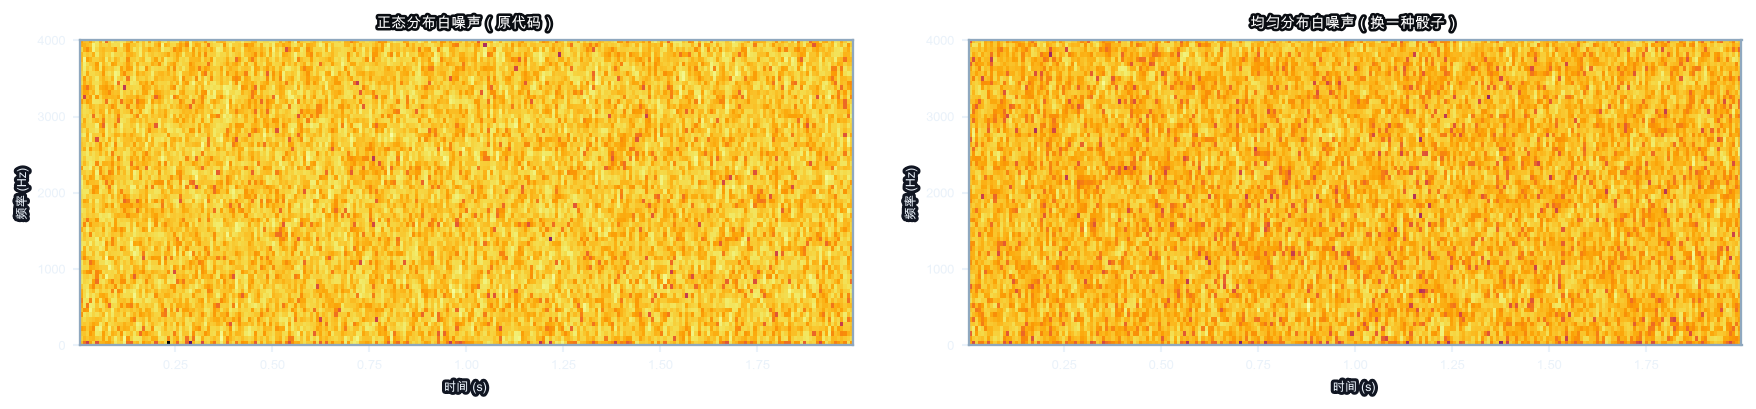

In [7]:
# 亲手验证："随机 = 全频率" 跟用哪种随机分布关系不大
# 把正态分布 (standard_normal) 换成均匀分布 (uniform)，谱图长得几乎一样
noise_uniform = rng.uniform(-1, 1, len(t))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
show_spec(noise,         sr, '正态分布白噪声（原代码）', axes[0])
show_spec(noise_uniform, sr, '均匀分布白噪声（换一种骰子）', axes[1])
plt.tight_layout(); plt.show()
print('两张图几乎一样：只要每个采样点独立地随机取值、不偏爱任何节奏，谱图就整片亮。')
print('「时间上独立随机 ⇔ 频率上全都有」的严格证明要等 L37 学了 DFT 才能给出，现在有直觉就够。')

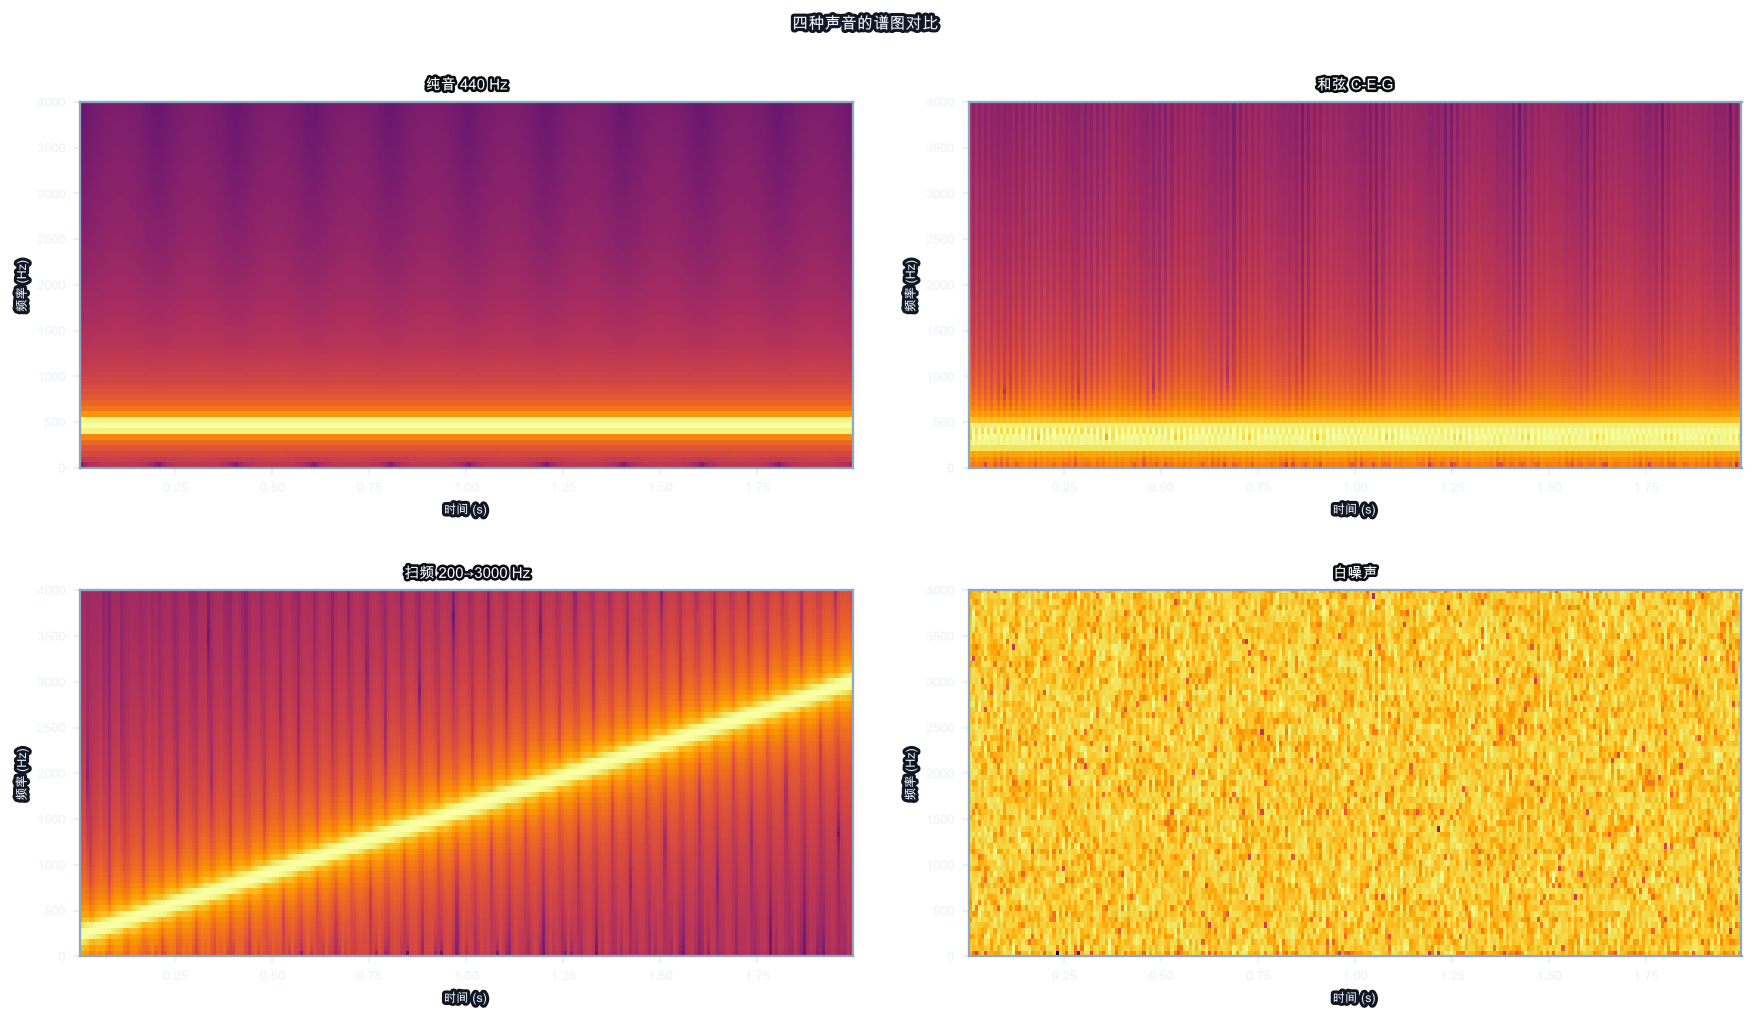

In [8]:
# 四种声音并排对比
signals = [
    (pure_tone, '纯音 440 Hz'),
    (chord,     '和弦 C-E-G'),
    (sweep,     '扫频 200→3000 Hz'),
    (noise,     '白噪声'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (sig, title) in zip(axes.flat, signals):
    show_spec(sig, sr, title, ax)
plt.suptitle('四种声音的谱图对比', fontsize=13)
plt.tight_layout(); plt.show()

## 2. 四种声音的"指纹"

声音学家说：每种声音都有自己的谱图"指纹"。看三分钟谱图，你就能认出它：

| 声音类型 | 谱图特征 | 类比 |
|---|---|---|
| 纯音（单频率）| 一条水平亮线 | 激光——能量集中在一个方向 |
| 和弦（多频率）| 多条平行水平线 | 彩虹——多种颜色叠加 |
| 扫频 | 一条斜线（从左下→右上）| 警报声从低到高爬升 |
| 白噪声（white noise） | 整幅图均匀亮 | 沙滩——所有频率同时随机响 |

**关键直觉**：谱图里的"亮度"就是能量密度。一根亮线意味着几乎所有能量都集中在那个频率，就像用放大镜把阳光聚到一点。

## 3. 语音谱图的特征

真实语音比上面复杂。下面会先出现三个名词——**先扫一眼即可，紧接着用人话拆开**；看不懂名词时不要停，直接读「三个画面」。

- **共振峰（Formants）**：声道的谐振频率，形成水平亮带，决定「哪个元音」
- **基频（F0 / Pitch）**：声带振动频率，男声约 100-200 Hz，女声约 180-300 Hz
- **清音/浊音**：浊音（voiced sound，如 a、e、i）有清晰的谐波（harmonics）结构；清音（unvoiced sound，如 s、f）更像噪声

Whisper 输入的就是这种谱图（Mel spectrogram 版本，L46-L47 实现）。

---

### 三个术语，先用人话搭好积木（读完这里，再回头看上面那三行就通了）

每个词只需要记一个画面：

- **基频（F0）**：声带每秒开合的次数。它决定音高——你哼歌时升调降调，变的就是它。
- **谐波（harmonics）**：声带振动时，除了基频本身，还会**同时**产生基频**整数倍**的一整排频率。
  基频 130 Hz 的嗓音，会带着 260、390、520、650……Hz 一起响，就像琴弦除了整根振动还会
  分两段、三段地同时振动（泛音）。在谱图上，谐波是**一排等间距的水平细线**。
  现在再读一遍上面第三条就通了：浊音（嗓子在震的音）有这排整齐的细线；
  清音（s、f 这类气流摩擦音）声带不震、没有这排线，看起来更像刚才的白噪声。
- **共振峰（formants）**：喉咙和嘴合起来像一个**可以变形的音箱**。嘴型一变，音箱就放大不同的
  频段——被放大的那几个频段就叫共振峰。刚才那句"声道的谐振频率"翻译成人话就是：
  "这个音箱天生偏爱放大的那几个频率"。在谱图上，共振峰是**水平亮带**：哪一片谐波被音箱加亮了，
  那一片就亮成一条带。

**最容易缠在一起的两个概念，一句话分开**：
谐波是"一排细线"，位置由**基频**决定（全是它的整数倍）；
共振峰是"哪几片区域被加亮"，位置由**嘴型**决定（不必是基频的整数倍，比如 700 Hz 就不是 130 的整数倍）。
发不同元音时基频可以完全不变（音高没变），变的是共振峰的位置——这就是 a、e、i 听起来不同的原因。

### 下一格代码里那堆数字是哪来的？（先交代，免得你猜）

- `700, 1200`（元音 a）、`400, 2200`（元音 e）、`300, 3000`（元音 i）：
  这些是**语音学家实际测量出来的典型共振峰位置**（每个人略有出入）。
  你不需要记住任何一个数，只要知道一句话：**不同元音 = 不同的共振峰位置组合**。
- 系数 `0.5 / 0.3 / 0.2`：只是让低频响一点、高频轻一点，模仿真嗓音"低频能量大"的大致趋势。
  随便改成别的比例，结论不变——欢迎自己改改看。
- **一个诚实的简化声明**：上一节刚说过，真实浊音是"一整排谐波细线 + 共振峰亮带"。
  但下一格的代码偷了个懒——只用 **3 个**正弦波，直接把亮带的**位置**各画成一条细线。
  所以你马上会看到三条细线而不是"带"，这不是矛盾，是简化。
  想看更接近真实的样子？下下格用 24 条谐波真的叠出"细线排 + 亮带"给你看。

观察：三段声音的高频共振带位置不同，这就是元音区分的关键。


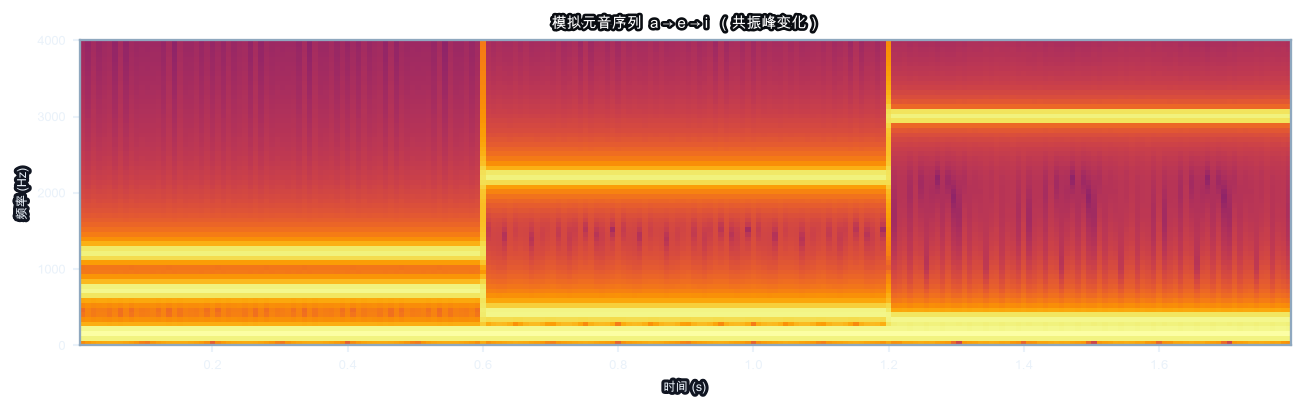

In [9]:
# 模拟「元音序列」：用不同共振峰组合近似 a / e / i
def vowel_approx(t, f0, f1, f2):
    """用基频 + 两个共振峰合成近似元音。"""
    return (
        0.5 * np.sin(2 * np.pi * f0 * t) +
        0.3 * np.sin(2 * np.pi * f1 * t) +
        0.2 * np.sin(2 * np.pi * f2 * t)
    )

seg_dur = 0.6
sr = 16000
t_seg = np.linspace(0, seg_dur, int(seg_dur * sr), endpoint=False)

# 简化的共振峰参数（非精确语音合成，仅用于谱图演示）
vowel_a = vowel_approx(t_seg, 130,  700, 1200)
vowel_e = vowel_approx(t_seg, 130,  400, 2200)
vowel_i = vowel_approx(t_seg, 130,  300, 3000)
combined = np.concatenate([vowel_a, vowel_e, vowel_i])

fig, ax = plt.subplots(figsize=(9, 3))
show_spec(combined, sr, '模拟元音序列  a → e → i  （共振峰变化）', ax, ylim=4000)
plt.tight_layout(); plt.show()
print('观察：三段声音的高频共振带位置不同，这就是元音区分的关键。')

读图：所有横线都在 130 Hz 的整数倍上（谐波，位置由基频决定）；
     700 和 1200 Hz 附近的横线明显更亮，聚成两条"亮带"（共振峰，位置由嘴型决定）。
     这就是 §3 那句话的画面：谐波是一排细线，共振峰是被加亮的带。


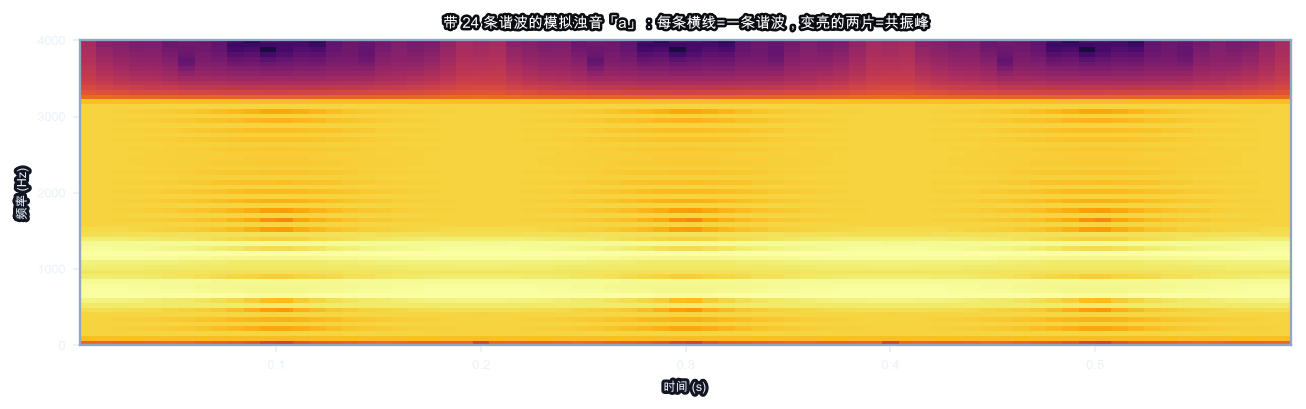

In [10]:
# 谐波 vs 共振峰：一张图同时看到"一排细线"和"水平亮带"
# 思路：声带发出基频 130 Hz 的一整排谐波（130, 260, 390, ...），
#       声道（喉咙+嘴）像可变形的音箱，把靠近共振峰（700 和 1200 Hz）的谐波放大。
f0_voice = 130                 # 基频：声带每秒开合 130 次
formant_centers = [700, 1200]  # 元音「a」的两个共振峰位置（语音学典型值）

def formant_gain(freq):
    """离共振峰中心越近，被放大得越多（钟形放大曲线，仅示意）。"""
    return 0.15 + sum(np.exp(-((freq - fc) / 150) ** 2) for fc in formant_centers)

# 叠加 24 条谐波：第 k 条谐波频率 = k × 130 Hz，响度由音箱的放大曲线决定
voiced = sum(
    formant_gain(k * f0_voice) * np.sin(2 * np.pi * k * f0_voice * t_seg)
    for k in range(1, 25) if k * f0_voice < sr / 2
)

fig, ax = plt.subplots(figsize=(9, 3))
show_spec(voiced, sr, '带 24 条谐波的模拟浊音「a」：每条横线=一条谐波，变亮的两片=共振峰', ax)
plt.tight_layout(); plt.show()
print('读图：所有横线都在 130 Hz 的整数倍上（谐波，位置由基频决定）；')
print('     700 和 1200 Hz 附近的横线明显更亮，聚成两条"亮带"（共振峰，位置由嘴型决定）。')
print('     这就是 §3 那句话的画面：谐波是一排细线，共振峰是被加亮的带。')

## ✏️ 练习：预测谱图形状

不运行代码，先用文字描述下面信号的谱图长什么样：

```python
sig_a = np.sin(2*np.pi*1000*t)  # 1000 Hz 纯音
sig_b = sig_a * np.linspace(1, 0, len(t))  # 振幅从 1 线性衰减到 0
sig_c = np.sin(2*np.pi*500*t) + np.sin(2*np.pi*1500*t)  # 两频率和
```

提示：除了频率（亮线在哪），也要想**亮度沿时间如何变**——能量轴经常被忘掉。

在下面 Markdown cell 里写预测，然后运行代码验证。

In [ ]:
# ✏️ 填写你的预测（运行这格之前写下答案，然后对照下一格的谱图）
predictions = {
    "sig_a_1000hz_pure": None,      # 描述 sig_a (1000 Hz 纯音) 的谱图形状
    "sig_b_decaying":    None,      # 描述 sig_b (1000 Hz 衰减) 的谱图形状
    "sig_c_chord":       None,      # 描述 sig_c (500 Hz + 1500 Hz 双频叠加) 的谱图形状
}

unfilled = [k for k, v in predictions.items() if v is None]
assert not unfilled, f'请先填写预测再继续：{unfilled}'
print('预测已记录，现在运行下一格看真实谱图，对比你的预测。')
for k, v in predictions.items():
    print(f'  {k}: {v}')

In [ ]:
sr = 16000
t  = np.linspace(0, 2, 2 * sr, endpoint=False)

sig_a = np.sin(2 * np.pi * 1000 * t)
sig_b = sig_a * np.linspace(1, 0, len(t))
sig_c = np.sin(2 * np.pi * 500 * t) + np.sin(2 * np.pi * 1500 * t)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, sig, title in zip(axes,
        [sig_a, sig_b, sig_c],
        ['sig_a：1000 Hz', 'sig_b：1000 Hz 衰减', 'sig_c：500 + 1500 Hz']):
    show_spec(sig, sr, title, ax)
plt.tight_layout(); plt.show()

### 逐行拆解下一格的"验证代码"（只会 print、变量、循环也能看懂）

下一格是全课唯一一段"用数字证明图没有骗你"的代码，里面有几个你还没学过的写法，先逐行翻译成人话：

1. `spectrum, freqs, _, _ = ax.specgram(...)`
   specgram 一次返回 4 样东西，我们只要前两样。**两个下划线 `_` 是 Python 的习惯写法，
   意思是"这两个返回值我不要，扔掉"**——它就是个普通变量名，只是约定俗成用来当垃圾桶。
2. `spectrum` 是一张二维表格，**形状 = (频率格数, 时间帧数)**，这里跑出来是 `(513, 17)`：
   每一**行**对应一个频率抽屉（bin），每一**列**对应一个时间片。
3. `spectrum.mean(axis=1)`：`axis=1` 表示**沿时间方向取平均**——把 17 个时间帧压扁成 1 列，
   得到"每个频率抽屉的平均能量"（513 个数）。好记的口诀：**axis=几，哪一维就被"吃掉"**
   （axis=1 吃掉第 1 维即时间帧，剩下频率维）。
   小心：如果误写成 `axis=0`，吃掉的就是频率维，argmax 找到的会是"能量最大的**时间帧**"，
   意思完全变了——而代码不会报错。这类"跑得通但意思错了"的坑，以后写 NumPy 要常防。
4. `.argmax()`：在这 513 个数里找出**最大值所在的位置（行号）**，注意返回的不是最大值本身。
5. `freqs[peak_bin]`：拿行号去 `freqs`（每一行对应的频率）里查出真正的频率数。

另外先打两针预防：

- 这一格的 `NFFT` 从前面一直用的 256 换成了 **1024**。没有阴谋：抽屉更窄
  （16000 ÷ 1024 = 15.625 Hz/格），频率定位更精细，验证起来更有说服力，仅此而已。
- 打印出来的峰值会是 **437.5 Hz，而不是 440 Hz**。别慌，这正是开头说的"带格子的尺子"：
  440 ÷ 15.625 = 28.16，落进第 28 号抽屉，抽屉的格线在 28 × 15.625 = **437.5 Hz**。
  差的这 2.5 Hz 不到半格宽，完全正常——`assert` 里 `< 20` 的容差就是为这种半格误差留的余量。

In [ ]:
# 验证：plt.specgram 返回的频率轴确认 440 Hz 纯音峰位于正确 bin
sr = 16000
t  = np.linspace(0, 1, sr, endpoint=False)
pure_tone = np.sin(2 * np.pi * 440 * t)

# specgram 返回 (spectrum, freqs, t_bins, im)；`_` = "这个返回值我不要"
# 注意：这里 NFFT 用 1024（不是前面的 256），抽屉更窄 = 频率定位更准，见上方拆解
fig, ax = plt.subplots(figsize=(6, 2))
spectrum, freqs, _, _ = ax.specgram(pure_tone, Fs=sr, NFFT=1024)
plt.close()

# 找峰值所在频率 bin
# spectrum 形状 = (频率格数, 时间帧数)；mean(axis=1) = 沿时间取平均，把各时间帧压成一条平均频谱
peak_bin = spectrum.mean(axis=1).argmax()
peak_freq = freqs[peak_bin]
print(f'峰值 bin 频率：{peak_freq:.1f} Hz（期望 ≈ 440 Hz）')
assert abs(peak_freq - 440) < 20, f'峰位偏差过大: {peak_freq:.1f} Hz'
print('✅ 440 Hz 纯音的谱图峰值落在正确频率 bin')

# 为什么打印的是 437.5 而不是 440？——频率尺子带格子（上一格已预告，这里用数字坐实）
bin_width = sr / 1024
nearest_gridline = round(440 / bin_width) * bin_width
print(f'spectrum 形状 = {spectrum.shape}（频率格数, 时间帧数）')
print(f'bin 宽度 = {bin_width:.3f} Hz；440 Hz 最近的格线 = {nearest_gridline:.1f} Hz —— 与峰值一致，图没有骗你')


## 本课收束

你现在能**看懂**谱图，但还不知道它是**怎么算出来**的。

| 直觉 | 数学 | 课程位置 |
|---|---|---|
| 频率 = Y 轴位置 | DFT 的输出频点 | L37-L39 |
| 能量 = 颜色亮度 | 复数模的平方 | L40-L41 |
| 时间方向一格一格往右走 ≈ 每次切一小段再分析（接 hop） | STFT；窗函数（window）在 L36 | L36, L43-L45 |
| Mel 版谱图 | Mel filterbank | L46-L47 |

音频 DSP 模块（L32–L53）结束时，你将能从零开始计算本课所有谱图——
包括 `plt.specgram` 内部的每一步，都会是你自己写的代码。

**下一课 L04**：正弦波三要素——频率、振幅、相位各控制什么，
掌握后再去看 L06 的欧拉公式，FFT 就有了具体的「砖头」。
---
⬇️ **通关检验**：收束小结已读；请完成下方「读谱图挑战」后再勾选自评。


## ✏️ 读谱图挑战：不看代码，只看图推断声音

**这是本课的核心练习。** 谱图比公式出现早——你在 L37 才会知道 FFT 怎么算，但你现在就要能读图。

---

**题目**：给你三幅谱图的文字描述，推断对应的声音类型：

**图A**：整幅图从上到下亮度均匀，没有特别亮的横线或斜线。
→ 这是什么声音？（纯音 / 和弦 / 扫频 / 白噪声）

**图B**：图中有三条水平亮线，分别在约 261 Hz、330 Hz、392 Hz 处，从左到右持续不变。
→ 这是什么声音？描述它的音乐含义。  
　（**白话也算对**：不必用「C 大三和弦」等术语——说「三个稳定音高同时响」即可。）

**图C**：图中有一条从左下角（200 Hz）爬升到右上角（3000 Hz）的斜亮线。
→ 这是什么声音？在音乐中对应什么演奏技法？  
　（**白话也算对**：说「音高连续爬升 / 警报声从低到高」即可，不必会 glissando 这个词。）

**图D**：图中有水平亮线，但亮度从左到右逐渐变暗，最后几乎消失。
→ 这是什么声音？

---

把你的答案写在下面验证格的字典里，代码会告诉你对不对。

In [ ]:
# ✏️ 把答案填入字典，然后运行对答案
import numpy as np

quiz_answers = {
    "图A": None,  # 填 '白噪声' / '纯音' / '和弦' / '扫频'
    "图B": None,  # 填 '和弦' + 说明（如 'C大调三和弦'）
    "图C": None,  # 填 '扫频' + 说明
    "图D": None,  # 填 '衰减纯音' 或描述
}

unfilled = [k for k, v in quiz_answers.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'

# 验证：答案应包含关键词
# （判卷程序只会做"关键词粗查"，读不懂人话；意思对但用词不同也算对，见运行结果末尾的说明）
correct = {
    "图A": ["白噪声", "noise", "随机", "所有频率", "全频"],
    "图B": ["和弦", "chord", "多频", "三和弦", "同时", "三个", "do", "mi", "sol", "c-e-g", "ceg"],
    "图C": ["扫频", "sweep", "glissando", "上行", "滑音", "爬升", "从低到高", "升高"],
    "图D": ["衰减", "decay", "envelope", "减弱", "变小", "变弱", "越来越", "消失", "渐弱", "变暗"],
}

all_correct = True
for fig, keywords in correct.items():
    ans = str(quiz_answers.get(fig, "")).lower()
    kw_lower = [k.lower() for k in keywords]
    if any(k in ans for k in kw_lower):
        print(f'  {fig} ✅')
    else:
        print(f'  {fig} ⚠️  与 §2 四种指纹对照后再填；勿在本格查答案关键词')
        all_correct = False

if all_correct:
    print('\n🎉 谱图读图挑战通过！你已经能用眼睛"听"声音了。')
else:
    print('\n💡 复习 §2 规律总结，再对照谱图图例，修改答案后重新运行。')
    print('📢 诚实声明：本格只做「关键词粗查」，不能真正读懂你的话。')
    print('   如果你的答案换个说法但意思对（比如图B写"三个音同时响"、图D写"声音越来越小"），')
    print('   那就算你答对——对照 §2 的指纹表自行确认即可，不必迁就判卷程序的用词。')

In [ ]:
# ✏️ 本课自评
l03_review = {
    "three_axes_understood":   None,  # 能说出谱图三轴含义（时间/频率/能量）？True/False
    "four_patterns_recognized": None, # 能识别四种声音的谱图指纹？True/False
    "prediction_exercise_done": None, # 预测练习在运行前填写了？True/False
    "quiz_passed":              None, # 读谱图挑战通过？True/False
}

unfilled = [k for k, v in l03_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l03_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L03 全部通关！进入 L04：正弦波三要素')

---

→ **下一课**　[L04 · 正弦波三要素](../1_complex_trig/L04_trig.ipynb)

> 下节课将学习 **正弦波三要素**：频率决定音高、振幅决定响度、相位决定起点，亲手实现。